In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import pickle
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.metrics import roc_auc_score

sns.set_style("ticks")  # Thiết lập style biểu đồ seaborn với các vạch chia trên trục

%matplotlib inline 
# Hiển thị biểu đồ trực tiếp trong Jupyter Notebook

In [10]:

medical = pd.read_csv("/home/vophilong/Documents/2526_2A_DeepLearning/lab_part_2/02 - Cross validation/medical_care.csv")
print(medical.shape) # In ra kích thước của DataFrame medical
pd.set_option("display.max_columns", 50) # Thiết lập để hiển thị tối đa 50 cột khi in DataFrameS
medical.head() # Hiển thị 5 dòng đầu tiên của DataFrame medical

(35072, 29)


,UMARSTAT,UCUREMP,UCURNINS,USATMED,URELATE,REGION,STATE,HHID,FHOSP,FDENT,FEMER,FDOCT,UIMMSTAT,U_USBORN,UAGE,U_FTPT,U_WKSLY,U_HRSLY,U_USHRS,HEARNVAL,HOTHVAL,HRETVAL,HSSVAL,HWSVAL,UBRACE,GENDER,UEDUC3,CEYES,CHAIR
0,Never married,No,Yes,Very satisfied,2,Midwest,WI,55616128,No,0,0,0,US-born citizen,Yes,22,Full-time,52.0,40,40,0,0,0,0,0,White,Female,No HS diploma or GED,hazel,brown
1,Separated,Yes,No,Very satisfied,2,Midwest,WI,54704000,No,2,0,0,US-born citizen,Yes,30,Full-time,52.0,40,40,31468,5950,0,0,31468,White,Female,"HS diploma or GED, no bachelor's degree",blue,black
2,Married_live together,No,No,Very satisfied,5,Midwest,WI,57874272,No,0,1,0,US-born citizen,Yes,33,Part-time,52.0,30,30,24700,11340,0,4920,24700,White,Male,No HS diploma or GED,brown,brown
3,Divorced,No,Yes,Little dissatisfied,4,Midwest,WI,54106816,No,0,0,1,US-born citizen,Yes,41,Part-time,43.0,40,25,60000,39002,0,0,60000,Black,Female,No HS diploma or GED,brown,black
4,Never married,Yes,No,Very satisfied,0,Midwest,WI,54569152,No,2,0,0,US-born citizen,Yes,34,Full-time,52.0,40,40,55280,4200,0,0,55280,Black,Male,"HS diploma or GED, no bachelor's degree",brown,black


Bây giờ hãy mã hóa (encode) biến UCURNINS và chạy mô hình hồi quy trên toàn bộ tập dữ liệu của chúng ta.

In [11]:
medical["UCURNINS"] = (medical.UCURNINS == "Yes").astype(int) # Chuyển đổi cột UCURNINS thành dạng số (1 nếu giá trị là "Yes", ngược lại là 0)

In [13]:
mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER', 
                          data = medical, # Dữ liệu được sử dụng để huấn luyện mô hình là DataFrame medicalS
                          family = sm.families.Binomial()) # Xây dựng mô hình hồi quy logistic với biến phụ thuộc là UCURNINS và các biến độc lập khác
res = mod.fit()# Thực hiện việc huấn luyện mô hình và lưu kết quả vào biến res
res.summary()# Hiển thị bảng tóm tắt kết quả của mô hình hồi quy logisticS

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               UCURNINS   No. Observations:                35072
Model:                            GLM   Df Residuals:                    35036
Model Family:                Binomial   Df Model:                           35
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11126.
Date:                Fri, 06 Mar 2026   Deviance:                       22251.
Time:                        13:29:29   Pearson chi2:                 4.05e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1742
Covariance Type:            nonrobust                                         
=====================================================================================================================
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             0.9019      0.216      4.166      0.000       0.478       1.326
UMARSTAT[T.Married, do not live together]            -0.4264      0.166     -2.563      0.010      -0.752      -0.100
UMARSTAT[T.Married_live together]                    -0.8331      0.056    -14.774      0.000      -0.944      -0.723
UMARSTAT[T.Never married]                            -0.3337      0.064     -5.210      0.000      -0.459      -0.208
UMARSTAT[T.Partnership]                               0.3966      0.085      4.677      0.000       0.230       0.563
UMARSTAT[T.Separated]                                -0.0527      0.095     -0.553      0.580      -0.239       0.134
UMARSTAT[T.Unknown]                                   0.6720      0.388      1.732      0.083      -0.089       1.433
UMARSTAT[T.Widowed]                                  -0.1727      0.144     -1.197      0.231      -0.455       0.110
USATMED[T.Little satisfied]                          -0.4597      0.063     -7.324      0.000      -0.583      -0.337
USATMED[T.No opinion]                                 0.6913      0.098      7.025      0.000       0.498       0.884
USATMED[T.Very dissatisfied]                          0.5547      0.092      6.017      0.000       0.374       0.735
USATMED[T.Very satisfied]                            -0.7287      0.062    -11.668      0.000      -0.851      -0.606
REGION[T.Northeast]                                  -0.0486      0.057     -0.858      0.391      -0.159       0.062
REGION[T.South]                                       0.7221      0.047     15.439      0.000       0.630       0.814
REGION[T.West]                                        0.4020      0.049      8.143      0.000       0.305       0.499
FHOSP[T.Yes]                                         -0.2438      0.075     -3.254      0.001      -0.391      -0.097
UIMMSTAT[T.Foreign-born, non-citizen]                 0.7271      0.089      8.172      0.000       0.553       0.901
UIMMSTAT[T.US-born citizen]                          -0.5706      0.080     -7.114      0.000      -0.728      -0.413
U_FTPT[T.Part-time]                                   0.4966      0.058      8.526      0.000       0.382       0.611
UBRACE[T.Asian/Pacific Islander]                     -0.9828      0.161     -6.104      0.000      -1.298      -0.667
UBRACE[T.Black]                                      -0.4685      0.126     -3.710      0.000      -0.716      -0.221
UBRACE[T.White]                                      -0.5119      0.118     -4.338      0.000      -0.743      -0.281
UEDUC3[T.HS diploma or GED, no bachelor's degree]     0.8375      0.053     15.828      0.000       0.734       0.941
UEDUC3[T.No HS 

Đối với việc chia dữ liệu đơn giản, chúng ta có thể sử dụng train_test_split. Phương thức này sẽ chia tập dữ liệu gồm các đặc trưng (features) và cột chứa biến phụ thuộc (dependent variable) của chúng ta. Chúng ta có thể xác định random_state hoặc khởi tạo nó bằng một số ngẫu nhiên. Việc kiểm soát tính ngẫu nhiên khi chia dữ liệu có thể giúp ích rất nhiều cho việc tái lập kết quả (reproducibility) trong một số trường hợp. Để thấy sự khác biệt, hãy chạy lại nhiều lần các cell ở phía trên và phía dưới.

In [14]:
from sklearn.model_selection import train_test_split
import random

X_train, X_test, y_train, y_test = train_test_split(medical,
                                                    medical.UCURNINS,
                                                    test_size = 0.3,
                                                    random_state = random.randint(0, 1000)) # Chia dữ liệu thành tập huấn luyện và tập kiểm tra với tỷ lệ 70% - 30% và sử dụng một giá trị ngẫu nhiên cho random_state để đảm bảo tính ngẫu nhiên trong việc chia dữ liệu
print(X_train.shape, X_test.shape) # In ra kích thước của tập huấn luyện X_train và tập kiểm tra X_test để xác nhận việc chia dữ liệu đã được thực hiện đúngS
mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = X_train, # Dữ liệu được sử dụng để huấn luyện mô hình là tập huấn luyện X_trainS
                          family = sm.families.Binomial()) # Xây dựng mô hình hồi quy logistic với biến phụ thuộc là UCURNINS và các biến độc lập khác, sử dụng tập huấn luyện X_train để huấn luyện mô hình
res = mod.fit()# Thực hiện việc huấn luyện mô hình và lưu kết quả vào biến resS
res.summary()# Hiển thị bảng tóm tắt kết quả của mô hình hồi quy logistic sau khi được huấn luyện trên tập huấn luyện X_trainSS
preds = res.predict(X_test)# Sử dụng mô hình đã huấn luyện để dự đoán xác suất của biến phụ thuộc UCURNINS trên tập kiểm tra X_test và lưu kết quả vào biến preds

roc_auc_score(y_test, preds)# Tính toán và in ra giá trị AUC-ROC để đánh giá hiệu suất của mô hình hồi quy logistic trên tập kiểm tra X_test, sử dụng biến y_test làm nhãn thực tế và biến preds làm xác suất dự đoán của mô hình.

(24550, 29) (10522, 29)


0.8314309148744696

Chúng ta có thể rất dễ dàng sử dụng stratify chỉ với một tham số. Chúng ta chỉ cần thiết lập cột dùng để phân tầng (stratification).

In [ ]:
scores = [] # Tạo một danh sách rỗng để lưu trữ các giá trị AUC-ROC từ mỗi lần chạy mô hình trên các tập huấn luyện và kiểm tra khác nhau

for k in range(100) : 
    
    X_train, X_test, y_train, y_test = train_test_split(medical,
                                                        medical.UCURNINS,
                                                        stratify = medical.UCURNINS,
                                                        test_size = 0.3,
                                                        random_state = random.randint(0, 10000))
    # print(X_train.shape, X_test.shape)
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = X_train,
                              family = sm.families.Binomial()) 
    res = mod.fit()
    res.summary()
    preds = res.predict(X_test)
    scores.append(roc_auc_score(y_test, preds)) # Tính toán và lưu giá trị AUC-ROC vào danh sách scores sau mỗi lần chạy mô hình trên các tập huấn luyện và kiểm tra khác nhau
    # print(scores[-1])

Chúng ta có thể rất dễ dàng sử dụng stratify chỉ với một tham số. Chúng ta chỉ cần thiết lập cột dùng để phân tầng (stratification).

In [16]:
medical.UCURNINS.value_counts() # Đếm số lượng giá trị duy nhất trong cột UCURNINS của DataFrame medical và in ra kết quả, giúp xác định số lượng mẫu thuộc mỗi lớp (0 và 1) trong biến phụ thuộc UCURNINS.

UCURNINS
0    30006
1     5066
Name: count, dtype: int64

In [17]:
df = pd.DataFrame(data = scores, columns = ['scores']) # Tạo một DataFrame mới có tên df từ danh sách scores, với một cột duy nhất có tên 'scores' chứa các giá trị AUC-ROC đã được lưu trữ trong danh sách scores.
print(df.scores.describe()) # Tính toán và in ra các chỉ số thống kê mô tả (như count, mean, std, min, 25%, 50%, 75%, max) cho cột scores trong DataFrame df, giúp hiểu rõ hơn về phân phối của các giá trị AUC-ROC đã được lưu trữ trong danh sách scores.
print(f'Kurtosis \t %s' %round(df.scores.kurtosis(), 5)) # Đây là 1 chỉ số thống kê mô tả độ nhọn của phân phối dữ liệu trong cột scores của DataFrame df, được làm tròn đến 5 chữ số thập phân và in ra kết quả với nhãn "Kurtosis"
print(f'Skewness \t %s' %round(df.scores.skew(), 5)) # Đây là 1 chỉ số thống kê mô tả độ lệch của phân phối dữ liệu trong cột scores của DataFrame df, được làm tròn đến 5 chữ số thập phân và in ra kết quả với nhãn "Skewness"

count    100.000000
mean       0.826985
std        0.003903
min        0.817345
25%        0.823873
50%        0.827324
75%        0.829696
max        0.834875
Name: scores, dtype: float64
Kurtosis 	 -0.3798
Skewness 	 -0.19578


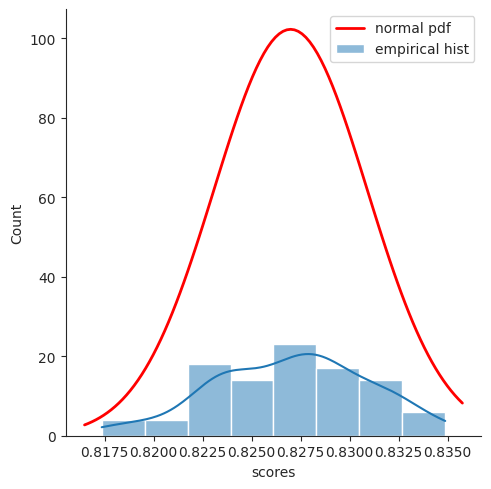

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

ax = sns.displot(data=df.scores, kde=True, label='empirical hist')

x0, x1 = ax.ax.get_xlim()
x_pdf = np.linspace(x0, x1, len(df))
y_pdf = stats.norm.pdf(x_pdf, df.scores.mean(), df.scores.std())

ax.ax.plot(x_pdf, y_pdf, 'r', lw=2, label='normal pdf')
ax.ax.legend()

In [20]:
from scipy import stats 

alpha = 1e-3

k2, p = stats.normaltest(df.scores) # Kurtosis and skewness normality test.

if p < alpha :

    print('Kurtosis, Skewness test: The null hypothesis about normality can be rejected.')

else:

    print('Kurtosis, Skewness test: The null hypothesis about normality can not be rejected.')

# Kolmogorov Smirnov normality test.
ks = stats.kstest(df.scores, 'norm')

if ks[1] < alpha :

    print('Kolmogorov Smirnov test: The null hypothesis about normality can be rejected.')

else:

    print('Kolmogorov Smirnov test: The null hypothesis about normality can not be rejected.')

# Do you remember that @kstest function requires NORMALIZATION of sample?
ks = stats.kstest((df.scores - df.scores.mean()) / df.scores.std(), 'norm')

if ks[1] < alpha :

    print('Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can be rejected.')

else:

    print('Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can not be rejected.')

Kurtosis, Skewness test: The null hypothesis about normality can not be rejected.
Kolmogorov Smirnov test: The null hypothesis about normality can be rejected.
Kolmogorov Smirnov (normalized sample) test: The null hypothesis about normality can not be rejected.


Bây giờ chúng ta có thể kiểm tra xu hướng bị overfitting trong hồi quy logistic. Như bạn có thể thấy bên dưới, chúng ta cần giảm kích thước tập dữ liệu huấn luyện xuống chỉ còn 10% thì mô hình mới thực sự bắt đầu bị overfitting. Điều này cho thấy mô hình có khả năng chống lại vấn đề overfitting khá tốt.

In [21]:
for k in range(1, 10) :
    
    X_train, X_test, y_train, y_test = train_test_split(medical,
                                                        medical.UCURNINS,
                                                        test_size = 0.1 * k,
                                                        random_state = 0)
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = X_train,
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(X_train)
    preds = res.predict(X_test)
    print("Train AUC:", round(roc_auc_score(y_train, predsTrain), 4), "Valid AUC:", round(roc_auc_score(y_test, preds), 4))

Train AUC: 0.8301 Valid AUC: 0.8196
Train AUC: 0.8305 Valid AUC: 0.8228
Train AUC: 0.8306 Valid AUC: 0.8242
Train AUC: 0.8293 Valid AUC: 0.8273
Train AUC: 0.8285 Valid AUC: 0.8278
Train AUC: 0.8327 Valid AUC: 0.8246
Train AUC: 0.8326 Valid AUC: 0.8251
Train AUC: 0.835 Valid AUC: 0.8227
Train AUC: 0.8514 Valid AUC: 0.8205


Đối với k-fold cross-validation (CV), chúng ta không nhận được trực tiếp các tập dữ liệu mà chỉ nhận được các chỉ số (indices) của các tập. Điều này được thực hiện để tránh việc sao chép dữ liệu không cần thiết. Hãy chạy 10-fold CV và xem kết quả. Đối với k-fold, chúng ta cần thêm tham số shuffle = True.

In [22]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    print("Train AUC:", round(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain), 4), "Valid AUC:",
          round(roc_auc_score(medical.iloc[test].UCURNINS, preds), 4))


Train AUC: 0.8304 Valid AUC: 0.8169
Train AUC: 0.8295 Valid AUC: 0.8256
Train AUC: 0.8287 Valid AUC: 0.833
Train AUC: 0.8295 Valid AUC: 0.8229
Train AUC: 0.8288 Valid AUC: 0.8296
Train AUC: 0.8296 Valid AUC: 0.822
Train AUC: 0.8304 Valid AUC: 0.8166
Train AUC: 0.8289 Valid AUC: 0.8291
Train AUC: 0.8284 Valid AUC: 0.8336
Train AUC: 0.827 Valid AUC: 0.8434


Như chúng ta có thể thấy, kết quả thay đổi khá nhiều giữa các mẫu khác nhau. Chúng ta thấy các giá trị từ 0.81 đến 0.838 trên các tập validation.

Để hiểu rõ hơn vấn đề phương sai (variance), hãy xem kết quả với 5-fold cross-validation. Phương sai của kết quả dường như thấp hơn một chút khi dùng 10-fold CV. Điều này là hợp lý vì hồi quy logistic không bị overfitting quá nhiều và khi chúng ta tăng kích thước của tập validation thì kết quả trên các tập validation sẽ ổn định hơn.

In [23]:
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())    
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    print("Train AUC:", round(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain), 4),
          "Valid AUC:", round(roc_auc_score(medical.iloc[test].UCURNINS, preds), 4))


Train AUC: 0.8294 Valid AUC: 0.8272
Train AUC: 0.8303 Valid AUC: 0.8225
Train AUC: 0.8293 Valid AUC: 0.8277
Train AUC: 0.8284 Valid AUC: 0.8298
Train AUC: 0.8284 Valid AUC: 0.8302


Hãy xem xét vấn đề phương sai (variance) chi tiết hơn. Chúng ta sẽ chạy 10-fold cross-validation 10 lần và quan sát phương sai của các giá trị trung bình.

In [24]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(medical.index.values):
        
        mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial())          
        res = mod.fit()
        predsTrain = res.predict(medical.iloc[train])
        preds = res.predict(medical.iloc[test])
        trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
        valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8291 Valid AUC: 0.8275
Train AUC: 0.8291 Valid AUC: 0.8271
Train AUC: 0.8291 Valid AUC: 0.8277
Train AUC: 0.8291 Valid AUC: 0.8274
Train AUC: 0.8291 Valid AUC: 0.8277
Train AUC: 0.8291 Valid AUC: 0.8274
Train AUC: 0.8291 Valid AUC: 0.8275
Train AUC: 0.8291 Valid AUC: 0.8277
Train AUC: 0.8291 Valid AUC: 0.8276
Train AUC: 0.8291 Valid AUC: 0.8275


Bây giờ hãy làm điều tương tự với 5-fold cross-validation (CV).

In [25]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(medical.index.values) :
        
        mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                              'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                              'UEDUC3 + GENDER',
                              data = medical.iloc[train],
                              family = sm.families.Binomial()) 
        res = mod.fit()
        predsTrain = res.predict(medical.iloc[train])
        preds = res.predict(medical.iloc[test])
        trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
        valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8292 Valid AUC: 0.8271
Train AUC: 0.8292 Valid AUC: 0.8273
Train AUC: 0.8292 Valid AUC: 0.8274
Train AUC: 0.8292 Valid AUC: 0.8272
Train AUC: 0.8292 Valid AUC: 0.8269
Train AUC: 0.8292 Valid AUC: 0.8275
Train AUC: 0.8292 Valid AUC: 0.8275
Train AUC: 0.8292 Valid AUC: 0.8277
Train AUC: 0.8292 Valid AUC: 0.8275
Train AUC: 0.8292 Valid AUC: 0.8272


Có vẻ như hồi quy logistic cho kết quả rất ổn định đối với cả 5-fold và 10-fold cross-validation. Hơn nữa, mô hình không bị overfitting nhiều, vì sự khác biệt giữa giá trị của chỉ số đánh giá (metric) trên tập train và tập validation là rất nhỏ.

In [26]:
predList = []
indList = []
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = medical.iloc[train],
                          family = sm.families.Binomial()) 
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(medical.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
    valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8292 Valid AUC: 0.8272


In [27]:
predsSorted = pd.Series(sum(predList, []), index = sum(indList, [])).sort_index()
roc_auc_score(medical.UCURNINS.sort_index(), pd.Series(sum(predList, []), index = sum(indList, [])).sort_index())

0.8271890430441349

In [28]:
from sklearn.model_selection import StratifiedKFold

predList = []
indList = []
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(medical.index.values, medical.UCURNINS) :
    
    mod = sm.GLM.from_formula(formula = 'UCURNINS ~ UMARSTAT + USATMED + URELATE + REGION + FHOSP + FDENT + FEMER + FDOCT + ' + 
                          'UIMMSTAT + UAGE + U_FTPT + U_WKSLY + U_USHRS + HOTHVAL + HRETVAL + HSSVAL + HWSVAL + UBRACE + ' + 
                          'UEDUC3 + GENDER',
                          data = medical.iloc[train],
                          family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(medical.iloc[train])
    preds = res.predict(medical.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(medical.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(medical.iloc[train].UCURNINS, predsTrain))
    valRes.append(roc_auc_score(medical.iloc[test].UCURNINS, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8292 Valid AUC: 0.8274


#### Nhưng đừng quên xem xét chất lượng tổng thể của mô hình...
Phần lớn mọi người đều có bảo hiểm, vì vậy chỉ cần đoán ngẫu nhiên rằng một người có bảo hiểm thì chúng ta đã đúng trong khoảng 85% trường hợp. Chất lượng tổng thể của mô hình của chúng ta chỉ cao hơn mức đó một chút.

In [29]:
print(f'Overall percent of uninsured persons is %s' %round(medical.UCURNINS.sum() / medical.UCURNINS.count() * 100, 2))

Overall percent of uninsured persons is 14.44


In [30]:
print(f'Quality score for training set is %s' 
      %round(sum(medical.UCURNINS.iloc[train] == (predsTrain > 0.5) * 1) / len(train) * 100, 2))
print(f'Quality score for test set is %s' 
      %round(sum(medical.UCURNINS.iloc[test] == (preds > 0.5) * 1) / len(test) * 100, 2))

Quality score for training set is 87.03
Quality score for test set is 86.9


In [ ]:
#--------------------------------------------------------------------
# Bài tập 2

# Bài tập 2.1

# Dữ liệu hành khách Titanic – gồm 1310 quan sát và 15 biến:

# passenger_id – ID hành khách duy nhất
# pclass – Hạng vé (1 = hạng nhất, 2 = hạng hai, 3 = hạng ba)
# survived – Tình trạng sống sót (0 = Không, 1 = Có)
# name – Tên và họ của hành khách
# sex – Giới tính (0 = Nam, 1 = Nữ)
# age – Tuổi (tính theo năm)
# sibsp – Số anh chị em hoặc vợ/chồng đi cùng trên tàu Titanic
# parch – Số cha mẹ hoặc con cái đi cùng trên tàu Titanic
# ticket – Số vé
# fare – Giá vé hành khách
# cabin – Số cabin
# embarked – Cảng lên tàu 
#            (C = Cherbourg, Q = Queenstown, S = Southampton)
# boat – Thuyền cứu sinh (nếu hành khách sống sót)
# body – Số hiệu thi thể (nếu hành khách không sống sót và thi thể được tìm thấy)
# home.dest – Nơi ở / điểm đến của hành khách
#
# Chạy lại các mô hình tốt nhất của bạn cho tất cả các thuật toán
# bằng phương pháp cross-validation 5-fold.
#
# Kiểm tra độ ổn định của kết quả khi sử dụng Repeated K-Fold.
#
# Kiểm tra trong Repeated K-Fold CV xem việc thêm stratification
# (phân tầng dữ liệu) có làm thay đổi độ ổn định của kết quả hay không.
#
# Kiểm tra xem mô hình của bạn có bị overfitting hay không.
#
# Kiểm tra xem bạn có thể cải thiện điểm validation của mô hình hay không.

In [34]:
titanic = pd.read_csv("/home/vophilong/Documents/2526_2A_DeepLearning/lab_part_2/02 - Cross validation/titanic.csv")
print(titanic.shape) # In ra kích thước của DataFrame titanic
pd.set_option("display.max_columns", 50) # Thiết lập để hiển thị tối đa 50 cột khi in DataFrameS
titanic.head() # Hiển thị 5 dòng đầu tiên của DataFrame titanic

(1309, 15)


,passenger_id,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,2,1,1,"Allison, Master. Hudson Trevor",0,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1,0,"Allison, Miss. Helen Loraine",1,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1,0,"Allison, Mr. Hudson Joshua Creighton",0,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
titanic["survived"] = (titanic.survived == 1).astype(int) # Chuyển đổi cột survived thành dạng số (1 nếu giá trị là 1, ngược lại là 0) để chuẩn bị cho việc huấn luyện mô hình hồi quy logisticS

In [ ]:
mod = sm.GLM.from_formula(
    formula='survived ~ pclass + sex + age + sibsp + parch + fare',
    data=titanic,
    family=sm.families.Binomial() # Xây dựng mô hình hồi quy logistic với biến phụ thuộc là survived và các biến độc lập khác, sử dụng toàn bộ dữ liệu titanic để huấn luyện mô hình
)

res = mod.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               survived   No. Observations:                 1045
Model:                            GLM   Df Residuals:                     1038
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -485.19
Date:                Fri, 06 Mar 2026   Deviance:                       970.37
Time:                        14:01:05   Pearson chi2:                 1.08e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3457
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.2297      0.436      5.114      0.000       1.375       3.084
pclass        -1.0982      0.131     -8.364      0.000      -1.356      -0.841
sex            2.5467      0.173     14.682      0.000       2.207       2.887
age           -0.0384      0.007     -5.862      0.000      -0.051      -0.026
sibsp         -0.3547      0.106     -3.351      0.001      -0.562      -0.147
parch          0.0549      0.103      0.533      0.594      -0.147       0.257
fare           0.0016      0.002      0.865      0.387      -0.002       0.005
==============================================================================
"""

In [41]:
titanic['age'] = titanic['age'].fillna(titanic['age'].mean()) # Điền giá trị thiếu trong cột age bằng giá trị trung bình của cột age để đảm bảo rằng mô hình hồi quy logistic có thể được huấn luyện mà không gặp lỗi do giá trị thiếu trong cột age
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].mean()) # Điền giá trị thiếu trong cột fare bằng giá trị trung bình của cột fare để đảm bảo rằng mô hình hồi quy logistic có thể được huấn luyện mà không gặp lỗi do giá trị thiếu trong cột fare

scores = []

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(
        titanic,
        titanic.survived,
        stratify=titanic.survived,
        test_size=0.3,
        random_state=random.randint(0, 10000)
    )

    mod = sm.GLM.from_formula(
        formula='survived ~ pclass + sex + age + sibsp + parch + fare',
        data=X_train,
        family=sm.families.Binomial()
    )

    res = mod.fit()

    preds = res.predict(X_test)

    scores.append(roc_auc_score(y_test, preds))

In [42]:
import numpy as np

print("Mean ROC AUC:", np.mean(scores))
print("Std:", np.std(scores))

Mean ROC AUC: 0.8380456790123456
Std: 0.019183603728207082


In [43]:
titanic.survived.value_counts() # Đếm số lượng giá trị duy nhất trong cột survived của DataFrame titanic và in ra kết quả, giúp xác định số lượng mẫu thuộc mỗi lớp (0 và 1) trong biến phụ thuộc survived.

survived
0    809
1    500
Name: count, dtype: int64

In [44]:
df = pd.DataFrame(data = scores, columns = ['scores'])
print(df.scores.describe())
print(f'Kurtosis \t %s' %round(df.scores.kurtosis(), 5)) # This one returns 'normalized' kurtosis (i.e. 0 instead of 3).
print(f'Skewness \t %s' %round(df.scores.skew(), 5))

count    100.000000
mean       0.838046
std        0.019280
min        0.783525
25%        0.825130
50%        0.839883
75%        0.850326
max        0.878313
Name: scores, dtype: float64
Kurtosis 	 -0.06888
Skewness 	 -0.30641


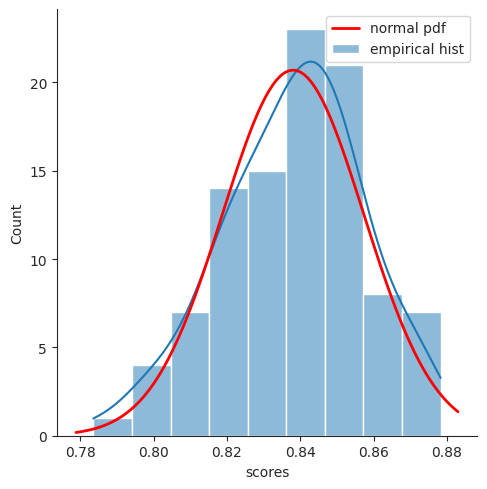

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.displot(data = df.scores, kde = True, label = 'empirical hist')
x0, x1 = ax.ax.get_xlim()
x_pdf = np.linspace(x0, x1, len(df))
y_pdf = stats.norm.pdf(x_pdf, df.scores.mean(), df.scores.std())
ax.ax.plot(x_pdf, y_pdf, 'r', lw = 2, label = 'normal pdf')
ax.ax.legend()

In [47]:
from scipy import stats

alpha = 1e-3  # Mức ý nghĩa thống kê (0.001)

# Kiểm định normality dựa trên Kurtosis và Skewness
k2, p = stats.normaltest(df.scores)  # Kiểm tra dữ liệu có phân phối chuẩn không

if p < alpha:
    print('Kurtosis, Skewness test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kurtosis, Skewness test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

# Kiểm định Kolmogorov-Smirnov cho phân phối chuẩn
ks = stats.kstest(df.scores, 'norm')

if ks[1] < alpha:
    print('Kolmogorov Smirnov test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kolmogorov Smirnov test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

# Lưu ý: hàm kstest cần dữ liệu được chuẩn hóa (mean=0, std=1)
ks = stats.kstest((df.scores - df.scores.mean()) / df.scores.std(), 'norm')

if ks[1] < alpha:
    print('Kolmogorov Smirnov (normalized sample) test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kolmogorov Smirnov (normalized sample) test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

Kurtosis, Skewness test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.
Kolmogorov Smirnov test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.
Kolmogorov Smirnov (normalized sample) test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.


In [48]:

for k in range(1, 10):

    X_train, X_test, y_train, y_test = train_test_split(
        titanic,
        titanic.survived,
        test_size=0.1 * k,
        random_state=0
    )

    mod = sm.GLM.from_formula(
        formula='survived ~ pclass + sex + age + sibsp + parch + fare',
        data=X_train,
        family=sm.families.Binomial()
    )

    res = mod.fit()

    predsTrain = res.predict(X_train)
    preds = res.predict(X_test)

    print(
        "Train AUC:", round(roc_auc_score(y_train, predsTrain), 4),
        "Valid AUC:", round(roc_auc_score(y_test, preds), 4)
    )

Train AUC: 0.8438 Valid AUC: 0.8229
Train AUC: 0.8415 Valid AUC: 0.8411
Train AUC: 0.843 Valid AUC: 0.8366
Train AUC: 0.8387 Valid AUC: 0.8442
Train AUC: 0.8411 Valid AUC: 0.8401
Train AUC: 0.8416 Valid AUC: 0.8399
Train AUC: 0.8449 Valid AUC: 0.8363
Train AUC: 0.8699 Valid AUC: 0.8233
Train AUC: 0.8816 Valid AUC: 0.8231


In [49]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(titanic.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'survived' + ' ~ pclass + sex + age + sibsp + parch + fare',
                              data = titanic.iloc[train],
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(titanic.iloc[train])
    preds = res.predict(titanic.iloc[test])
    print("Train AUC:", round(roc_auc_score(titanic.iloc[train].survived, predsTrain), 4), "Valid AUC:",
          round(roc_auc_score(titanic.iloc[test].survived, preds), 4))

Train AUC: 0.8429 Valid AUC: 0.8259
Train AUC: 0.8422 Valid AUC: 0.8292
Train AUC: 0.8375 Valid AUC: 0.8788
Train AUC: 0.8463 Valid AUC: 0.7908
Train AUC: 0.8399 Valid AUC: 0.8587
Train AUC: 0.8444 Valid AUC: 0.8212
Train AUC: 0.8393 Valid AUC: 0.8605
Train AUC: 0.8421 Valid AUC: 0.8364
Train AUC: 0.8415 Valid AUC: 0.8389
Train AUC: 0.8419 Valid AUC: 0.8381


In [50]:
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(titanic.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'survived' + ' ~ pclass + sex + age + sibsp + parch + fare',
                              data = titanic.iloc[train],
                              family = sm.families.Binomial())    
    res = mod.fit()
    predsTrain = res.predict(titanic.iloc[train])
    preds = res.predict(titanic.iloc[test])
    print("Train AUC:", round(roc_auc_score(titanic.iloc[train].survived, predsTrain), 4),
          "Valid AUC:", round(roc_auc_score(titanic.iloc[test].survived, preds), 4))


Train AUC: 0.8416 Valid AUC: 0.8388
Train AUC: 0.8415 Valid AUC: 0.8418
Train AUC: 0.8513 Valid AUC: 0.7973
Train AUC: 0.8413 Valid AUC: 0.8397
Train AUC: 0.8327 Valid AUC: 0.8768


In [51]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(titanic.index.values):
        
        mod = sm.GLM.from_formula(formula = 'survived' + ' ~ pclass + sex + age + sibsp + parch + fare',
                              data = titanic.iloc[train],
                              family = sm.families.Binomial())          
        res = mod.fit()
        predsTrain = res.predict(titanic.iloc[train])
        preds = res.predict(titanic.iloc[test])
        trainRes.append(roc_auc_score(titanic.iloc[train].survived, predsTrain))
        valRes.append(roc_auc_score(titanic.iloc[test].survived, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))


Train AUC: 0.8418 Valid AUC: 0.84
Train AUC: 0.8416 Valid AUC: 0.8391
Train AUC: 0.8417 Valid AUC: 0.8417
Train AUC: 0.8418 Valid AUC: 0.841
Train AUC: 0.8417 Valid AUC: 0.8398
Train AUC: 0.8418 Valid AUC: 0.837
Train AUC: 0.8417 Valid AUC: 0.838
Train AUC: 0.8416 Valid AUC: 0.8374
Train AUC: 0.8418 Valid AUC: 0.8434
Train AUC: 0.8419 Valid AUC: 0.8413


In [52]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(titanic.index.values) :
        
        mod = sm.GLM.from_formula(formula = 'survived' + ' ~ pclass + sex + age + sibsp + parch + fare',
                              data = titanic.iloc[train],
                              family = sm.families.Binomial()) 
        res = mod.fit()
        predsTrain = res.predict(titanic.iloc[train])
        preds = res.predict(titanic.iloc[test])
        trainRes.append(roc_auc_score(titanic.iloc[train].survived, predsTrain))
        valRes.append(roc_auc_score(titanic.iloc[test].survived, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8417 Valid AUC: 0.8392
Train AUC: 0.8419 Valid AUC: 0.8396
Train AUC: 0.8416 Valid AUC: 0.8384
Train AUC: 0.8418 Valid AUC: 0.838
Train AUC: 0.8416 Valid AUC: 0.8394
Train AUC: 0.8418 Valid AUC: 0.8385
Train AUC: 0.842 Valid AUC: 0.8371
Train AUC: 0.8414 Valid AUC: 0.84
Train AUC: 0.8417 Valid AUC: 0.8372
Train AUC: 0.8417 Valid AUC: 0.8392


In [53]:
predList = []
indList = []
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(titanic.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'survived' + ' ~ pclass + sex + age + sibsp + parch + fare',
                          data = titanic.iloc[train],
                          family = sm.families.Binomial()) 
    res = mod.fit()
    predsTrain = res.predict(titanic.iloc[train])
    preds = res.predict(titanic.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(titanic.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(titanic.iloc[train].survived, predsTrain))
    valRes.append(roc_auc_score(titanic.iloc[test].survived, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8418 Valid AUC: 0.8397


In [54]:
predsSorted = pd.Series(sum(predList, []), index = sum(indList, [])).sort_index()
roc_auc_score(titanic.survived.sort_index(), pd.Series(sum(predList, []), index = sum(indList, [])).sort_index())

0.837646477132262

In [55]:
from sklearn.model_selection import StratifiedKFold

predList = []
indList = []
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(titanic.index.values, titanic.survived) :
    
    mod = sm.GLM.from_formula(formula = 'survived ~ pclass + sex + age + sibsp + parch + fare',
                          data = titanic.iloc[train],
                          family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(titanic.iloc[train])
    preds = res.predict(titanic.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(titanic.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(titanic.iloc[train].survived, predsTrain))
    valRes.append(roc_auc_score(titanic.iloc[test].survived, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8418 Valid AUC: 0.8398


In [56]:
print(f'Tỷ lệ hành khách sống sót là %s%%' % round(titanic.survived.sum() / titanic.survived.count() * 100, 2))

Tỷ lệ hành khách sống sót là 38.2%


In [57]:
print(f'Độ chính xác (quality score) của tập huấn luyện là %s'
      % round(sum(titanic.survived.iloc[train] == (predsTrain > 0.5) * 1) / len(train) * 100, 2))

print(f'Độ chính xác (quality score) của tập kiểm tra là %s'
      % round(sum(titanic.survived.iloc[test] == (preds > 0.5) * 1) / len(test) * 100, 2))

Độ chính xác (quality score) của tập huấn luyện là 78.53
Độ chính xác (quality score) của tập kiểm tra là 80.46


In [31]:
# Exercise 2.2.

# Bộ dữ liệu chất lượng rượu vang: "data/wines.csv"
# nguồn: https://archive.ics.uci.edu/ml/datasets/wine+quality

# File này chứa dữ liệu về các mẫu rượu vang trắng và đỏ của Bồ Đào Nha
# có tên là Vinho Verde.

# Các đặc tính hóa lý (physico-chemical) khác nhau của từng mẫu rượu
# được cung cấp trong dữ liệu, cùng với điểm đánh giá chất lượng rượu
# theo thang điểm từ 0 đến 10 do các chuyên gia chấm.

# Chạy lại các mô hình tốt nhất của bạn cho tất cả các thuật toán
# bằng phương pháp cross-validation 5-fold.

# Kiểm tra độ ổn định của kết quả khi sử dụng Repeated K-Fold.

# Kiểm tra trong Repeated K-Fold CV xem việc thêm stratification
# (phân tầng dữ liệu) có làm thay đổi độ ổn định của kết quả hay không.

# So sánh ảnh hưởng của stratification với bài toán Titanic.

# Kiểm tra xem mô hình của bạn có bị overfitting hay không.

# Kiểm tra xem bạn có thể cải thiện điểm validation của mô hình hay không.

In [59]:
wire = pd.read_csv("/home/vophilong/Documents/2526_2A_DeepLearning/lab_part_2/02 - Cross validation/wines.csv")
print(wire.shape) # In ra kích thước của DataFrame rượu vang
pd.set_option("display.max_columns", 50) # Thiết lập để hiển thị tối đa 50 cột khi in DataFrame
wire.head() # Hiển thị 5 dòng đầu tiên của DataFrame rượu vang

(6497, 13)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,type,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,red,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,red,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,red,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5


In [61]:
wire["good_wine"] = (wire.quality >= 6).astype(int)

In [62]:
mod = sm.GLM.from_formula(
    formula='good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
    data=wire,
    family=sm.families.Binomial()
)

res = mod.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              good_wine   No. Observations:                 6497
Model:                            GLM   Df Residuals:                     6485
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3353.1
Date:                Fri, 06 Mar 2026   Deviance:                       6706.2
Time:                        14:28:56   Pearson chi2:                 6.75e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2460
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               48.4858     39.812      1.218      0.223     -29.544     126.516
fixed_acidity            0.0823      0.051      1.614      0.106      -0.018       0.182
volatile_acidity        -4.4235      0.275    -16.086      0.000      -4.962      -3.885
citric_acid             -0.5889      0.254     -2.322      0.020      -1.086      -0.092
residual_sugar           0.0881      0.017      5.205      0.000       0.055       0.121
chlorides               -0.9203      1.033     -0.891      0.373      -2.946       1.105
free_sulfur_dioxide      0.0166      0.003      6.614      0.000       0.012       0.022
total_sulfur_dioxide    -0.0077      0.001     -8.594      0.000      -0.009      -0.006
density                -59.5085     40.606     -1.466      0.143    -139.094      20.077
pH                       0.7029      0.299      2.352      0.019       0.117       1.289
sulphates                2.1195      0.266      7.978      0.000       1.599       2.640
alcohol                  0.8685      0.059     14.675      0.000       0.752       0.984
========================================================================================
"""

In [65]:
scores = []

for k in range(100) :
    
    X_train, X_test, y_train, y_test = train_test_split(wire,
                                                        wire.good_wine,
                                                        stratify = wire.good_wine,
                                                        test_size = 0.3,
                                                        random_state = random.randint(0, 10000))
    # print(X_train.shape, X_test.shape)
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = X_train,
                              family = sm.families.Binomial())
    res = mod.fit()
    res.summary()
    preds = res.predict(X_test)
    scores.append(roc_auc_score(y_test, preds))
    # print(scores[-1])

In [66]:
wire.good_wine.value_counts()

good_wine
1    4113
0    2384
Name: count, dtype: int64

In [67]:
df = pd.DataFrame(data = scores, columns = ['scores'])
print(df.scores.describe())
print(f'Kurtosis \t %s' %round(df.scores.kurtosis(), 5)) # This one returns 'normalized' kurtosis (i.e. 0 instead of 3).
print(f'Skewness \t %s' %round(df.scores.skew(), 5))

count    100.000000
mean       0.800062
std        0.008416
min        0.780382
25%        0.793773
50%        0.801673
75%        0.805753
max        0.817705
Name: scores, dtype: float64
Kurtosis 	 -0.47467
Skewness 	 -0.13605


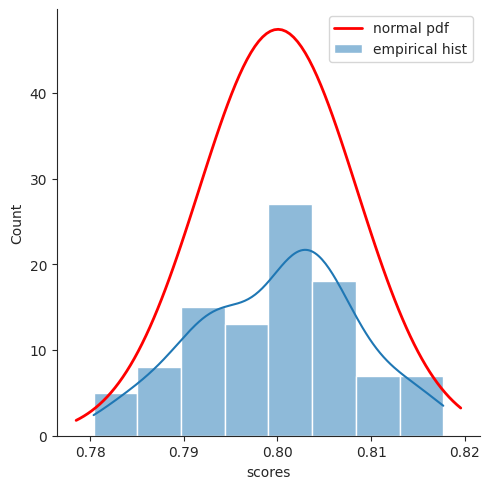

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.displot(data = df.scores, kde = True, label = 'empirical hist')
x0, x1 = ax.ax.get_xlim()
x_pdf = np.linspace(x0, x1, len(df))
y_pdf = stats.norm.pdf(x_pdf, df.scores.mean(), df.scores.std())
ax.ax.plot(x_pdf, y_pdf, 'r', lw = 2, label = 'normal pdf')
ax.ax.legend()

In [69]:
from scipy import stats

alpha = 1e-3  # Mức ý nghĩa thống kê (0.001)

# Kiểm định normality dựa trên Kurtosis và Skewness
k2, p = stats.normaltest(df.scores)  # Kiểm tra dữ liệu có phân phối chuẩn không

if p < alpha:
    print('Kurtosis, Skewness test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kurtosis, Skewness test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

# Kiểm định Kolmogorov-Smirnov cho phân phối chuẩn
ks = stats.kstest(df.scores, 'norm')

if ks[1] < alpha:
    print('Kolmogorov Smirnov test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kolmogorov Smirnov test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

# Lưu ý: hàm kstest cần dữ liệu được chuẩn hóa (mean=0, std=1)
ks = stats.kstest((df.scores - df.scores.mean()) / df.scores.std(), 'norm')

if ks[1] < alpha:
    print('Kolmogorov Smirnov (normalized sample) test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')
else:
    print('Kolmogorov Smirnov (normalized sample) test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.')

Kurtosis, Skewness test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.
Kolmogorov Smirnov test: Bác bỏ giả thuyết dữ liệu có phân phối chuẩn.
Kolmogorov Smirnov (normalized sample) test: Không thể bác bỏ giả thuyết dữ liệu có phân phối chuẩn.


In [70]:
for k in range(1, 10) :
    
    X_train, X_test, y_train, y_test = train_test_split(wire,
                                                        wire.good_wine,
                                                        test_size = 0.1 * k,
                                                        random_state = 0)
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = X_train,
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(X_train)
    preds = res.predict(X_test)
    print("Train AUC:", round(roc_auc_score(y_train, predsTrain), 4), "Valid AUC:", round(roc_auc_score(y_test, preds), 4))


Train AUC: 0.8037 Valid AUC: 0.7959
Train AUC: 0.8046 Valid AUC: 0.796
Train AUC: 0.8085 Valid AUC: 0.7898
Train AUC: 0.8106 Valid AUC: 0.7908
Train AUC: 0.8067 Valid AUC: 0.7981
Train AUC: 0.8106 Valid AUC: 0.7966
Train AUC: 0.8193 Valid AUC: 0.7937
Train AUC: 0.8134 Valid AUC: 0.7967
Train AUC: 0.8133 Valid AUC: 0.7935


In [71]:
from sklearn.model_selection import KFold

kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(wire.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = wire.iloc[train],
                              family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(wire.iloc[train])
    preds = res.predict(wire.iloc[test])
    print("Train AUC:", round(roc_auc_score(wire.iloc[train].good_wine, predsTrain), 4), "Valid AUC:",
          round(roc_auc_score(wire.iloc[test].good_wine, preds), 4))


Train AUC: 0.7989 Valid AUC: 0.842
Train AUC: 0.8032 Valid AUC: 0.8009
Train AUC: 0.803 Valid AUC: 0.802
Train AUC: 0.8081 Valid AUC: 0.7551
Train AUC: 0.8043 Valid AUC: 0.7906
Train AUC: 0.8024 Valid AUC: 0.8072
Train AUC: 0.8003 Valid AUC: 0.8263
Train AUC: 0.8028 Valid AUC: 0.8029
Train AUC: 0.8046 Valid AUC: 0.7864
Train AUC: 0.803 Valid AUC: 0.8002


In [72]:
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(wire.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = wire.iloc[train],
                              family = sm.families.Binomial())    
    res = mod.fit()
    predsTrain = res.predict(wire.iloc[train])
    preds = res.predict(wire.iloc[test])
    print("Train AUC:", round(roc_auc_score(wire.iloc[train].good_wine, predsTrain), 4),
          "Valid AUC:", round(roc_auc_score(wire.iloc[test].good_wine, preds), 4))


Train AUC: 0.8011 Valid AUC: 0.8095
Train AUC: 0.8014 Valid AUC: 0.8079
Train AUC: 0.8063 Valid AUC: 0.7895
Train AUC: 0.8072 Valid AUC: 0.7856
Train AUC: 0.8002 Valid AUC: 0.813


In [73]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 10, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(wire.index.values):
        
        mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = wire.iloc[train],
                              family = sm.families.Binomial())          
        res = mod.fit()
        predsTrain = res.predict(wire.iloc[train])
        preds = res.predict(wire.iloc[test])
        trainRes.append(roc_auc_score(wire.iloc[train].good_wine, predsTrain))
        valRes.append(roc_auc_score(wire.iloc[test].good_wine, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))


Train AUC: 0.8031 Valid AUC: 0.8016
Train AUC: 0.8031 Valid AUC: 0.8019
Train AUC: 0.8031 Valid AUC: 0.8011
Train AUC: 0.8031 Valid AUC: 0.8017
Train AUC: 0.8031 Valid AUC: 0.8011
Train AUC: 0.8031 Valid AUC: 0.8012
Train AUC: 0.8031 Valid AUC: 0.8013
Train AUC: 0.8031 Valid AUC: 0.8021
Train AUC: 0.8031 Valid AUC: 0.8008
Train AUC: 0.8031 Valid AUC: 0.8014


In [74]:
for z in range(10) :
    
    trainRes = []
    valRes = []
    kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))
    
    for train, test in kf.split(wire.index.values) :
        
        mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                              data = wire.iloc[train],
                              family = sm.families.Binomial()) 
        res = mod.fit()
        predsTrain = res.predict(wire.iloc[train])
        preds = res.predict(wire.iloc[test])
        trainRes.append(roc_auc_score(wire.iloc[train].good_wine, predsTrain))
        valRes.append(roc_auc_score(wire.iloc[test].good_wine, preds))
        
    print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8032 Valid AUC: 0.8016
Train AUC: 0.8032 Valid AUC: 0.8016
Train AUC: 0.8033 Valid AUC: 0.801
Train AUC: 0.8032 Valid AUC: 0.8011
Train AUC: 0.8032 Valid AUC: 0.8008
Train AUC: 0.8032 Valid AUC: 0.8012
Train AUC: 0.8032 Valid AUC: 0.8011
Train AUC: 0.8031 Valid AUC: 0.8017
Train AUC: 0.8032 Valid AUC: 0.8012
Train AUC: 0.8033 Valid AUC: 0.801


In [75]:
predList = []
indList = []
kf = KFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(wire.index.values) :
    
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                          data = wire.iloc[train],
                          family = sm.families.Binomial()) 
    res = mod.fit()
    predsTrain = res.predict(wire.iloc[train])
    preds = res.predict(wire.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(wire.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(wire.iloc[train].good_wine, predsTrain))
    valRes.append(roc_auc_score(wire.iloc[test].good_wine, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8033 Valid AUC: 0.8007


In [76]:
predsSorted = pd.Series(sum(predList, []), index = sum(indList, [])).sort_index()
roc_auc_score(wire.good_wine.sort_index(), pd.Series(sum(predList, []), index = sum(indList, [])).sort_index())

0.7996357514314574

In [77]:
from sklearn.model_selection import StratifiedKFold

predList = []
indList = []
kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = random.randint(0, 10000))

for train, test in kf.split(wire.index.values, wire.good_wine) :
    
    mod = sm.GLM.from_formula(formula = 'good_wine ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + '
            'chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + '
            'sulphates + alcohol',
                          data = wire.iloc[train],
                          family = sm.families.Binomial())
    res = mod.fit()
    predsTrain = res.predict(wire.iloc[train])
    preds = res.predict(wire.iloc[test])
    
    predList.append(preds.tolist())
    indList.append(wire.iloc[test].index.tolist())
    
    trainRes.append(roc_auc_score(wire.iloc[train].good_wine, predsTrain))
    valRes.append(roc_auc_score(wire.iloc[test].good_wine, preds))
    
print("Train AUC:", round(np.mean(trainRes), 4), "Valid AUC:", round(np.mean(valRes), 4))

Train AUC: 0.8033 Valid AUC: 0.8009


In [78]:
print(f'Tỷ lệ rượu chất lượng tốt là %s%%'
      % round(wire.good_wine.sum() / wire.good_wine.count() * 100, 2))

Tỷ lệ rượu chất lượng tốt là 63.31%


In [79]:
print(f'Độ chính xác của tập huấn luyện là %s'
      % round(sum(wire.good_wine.iloc[train] == (predsTrain > 0.5) * 1) / len(train) * 100, 2))

print(f'Độ chính xác của tập kiểm tra là %s'
      % round(sum(wire.good_wine.iloc[test] == (preds > 0.5) * 1) / len(test) * 100, 2))

Độ chính xác của tập huấn luyện là 74.45
Độ chính xác của tập kiểm tra là 72.9
